# Multiplicative Constant Ablation: Figure 4 Right

This notebook reproduces the right panel of report Figure 4, where the hierarchy strength is varied through the teacher multiplicative constant `m`.


In [1]:
from analysis.utils import (
    REPORT_BLUE,
    REPORT_GREEN,
    REPORT_LINEWIDTH,
    REPORT_YELLOW,
    differing_config,
    fetch_runs,
    get_runs_data,
    style_report_axis,
)
import matplotlib.pyplot as plt


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
runs = fetch_runs(tags_any=["ablation-mc"])
df = get_runs_data(runs, metrics=["val_loss", "teacher_val_loss"])
differing_config(df.drop(columns=["cfg.teacher.span_lengths"], errors="ignore"))


,_run_id,_run_name,cfg.teacher.multiplicative_constant
0,0gwnw5pp,hardy-water-1694,1.9
1,aauvrhna,neat-snowball-1693,2.1
2,f6ptx37n,visionary-wave-1690,1.0
3,ncbjp03f,faithful-violet-1691,1.3
4,xnmn38ft,splendid-glitter-1692,1.5


## Figure 4 Right: Excess Loss By Importance Hierarchy

Larger `m` separates the feature-group importances more strongly, which makes the staged plateaus easier to distinguish.


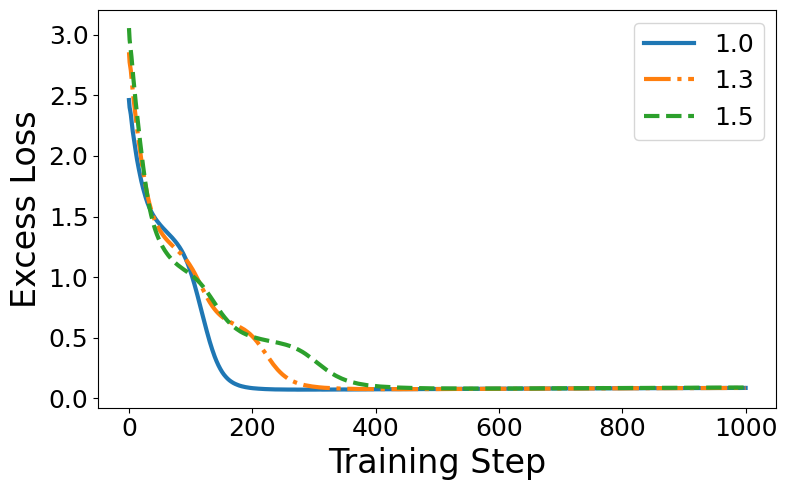

In [3]:
max_step = 1000
fig, ax = plt.subplots(figsize=(8, 5))
groups = df.groupby(["_run_name", "cfg.teacher.multiplicative_constant"], dropna=False)[
    ["_step", "val_loss", "teacher_val_loss"]
]

styles = {
    1.0: (REPORT_BLUE, "-"),
    1.3: (REPORT_YELLOW, "-."),
    1.5: (REPORT_GREEN, "--"),
}

for (_, m_value), data in sorted(groups, key=lambda item: item[0][1]):
    if float(m_value) not in styles:
        continue
    data = data.sort_values("_step").copy()
    data["relative_step"] = data["_step"] - data["_step"].min()
    data = data[data["relative_step"] <= max_step]
    teacher_val_loss = data["teacher_val_loss"].dropna().unique()[0]
    color, linestyle = styles[float(m_value)]
    ax.plot(
        data["relative_step"],
        data["val_loss"].to_numpy() - teacher_val_loss,
        label=f"{m_value:.1f}",
        color=color,
        linestyle=linestyle,
        linewidth=REPORT_LINEWIDTH,
    )

style_report_axis(ax, xlabel="Training Step", ylabel="Excess Loss", legend=True)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(output_path("multiplicative-constant-excess-loss.pdf"), bbox_inches="tight", dpi=300)
else:
    plt.show()
